In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

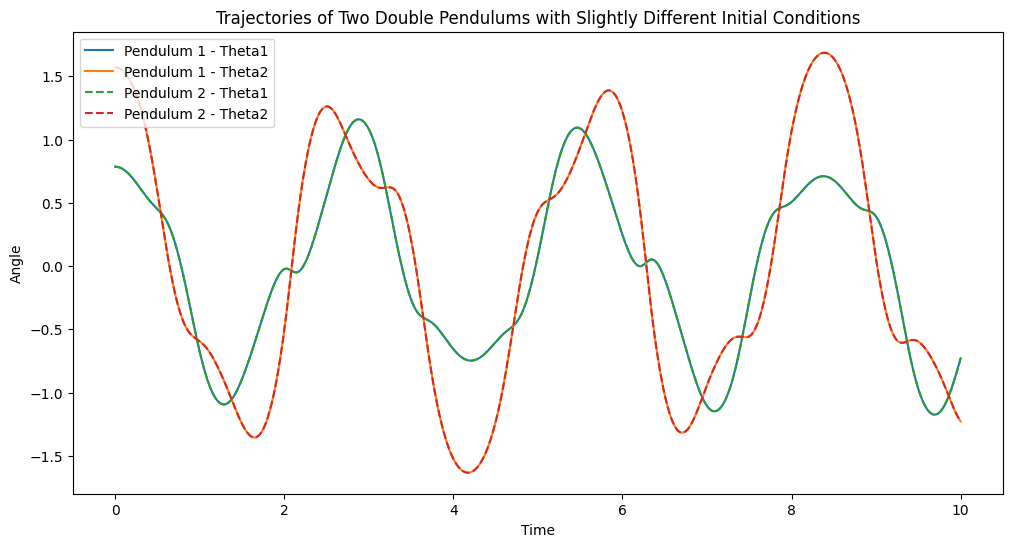

In [9]:
def double_pendulum(t, y, L1, L2, m1, m2):
    theta1, z1, theta2, z2 = y
    c, s = np.cos(theta1-theta2), np.sin(theta1-theta2)
    
    theta1dot = z1
    z1dot = (m2*9.81*np.sin(theta2)*c - m2*s*(L1*z1**2*c + L2*z2**2) - (m1+m2)*9.81*np.sin(theta1)) / L1 / (m1 + m2*s**2)
    theta2dot = z2
    z2dot = ((m1+m2)*(L1*z1**2*s - 9.81*np.sin(theta2) + 9.81*np.sin(theta1)*c) + m2*L2*z2**2*s*c) / L2 / (m1 + m2*s**2)
    
    return [theta1dot, z1dot, theta2dot, z2dot]

# Initial conditions
y0_1 = [np.pi/4, 0, np.pi/2, 0]
y0_2 = [np.pi/4 + 1e-8, 0, np.pi/2, 0]
t_span = [0, 10]
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Parameters
L1, L2 = 1.0, 1.0
m1, m2 = 1.0, 1.0

# Solve ODE for both initial conditions
sol_1 = solve_ivp(double_pendulum, t_span, y0_1, args=(L1, L2, m1, m2), t_eval=t_eval)
sol_2 = solve_ivp(double_pendulum, t_span, y0_2, args=(L1, L2, m1, m2), t_eval=t_eval)

# Plot trajectories
plt.figure(figsize=(12, 6))
plt.plot(sol_1.t, sol_1.y[0], label='Pendulum 1 - Theta1')
plt.plot(sol_1.t, sol_1.y[2], label='Pendulum 1 - Theta2')
plt.plot(sol_2.t, sol_2.y[0], label='Pendulum 2 - Theta1', linestyle='dashed')
plt.plot(sol_2.t, sol_2.y[2], label='Pendulum 2 - Theta2', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Angle')
plt.legend()
plt.title('Trajectories of Two Double Pendulums with Slightly Different Initial Conditions')
plt.show()


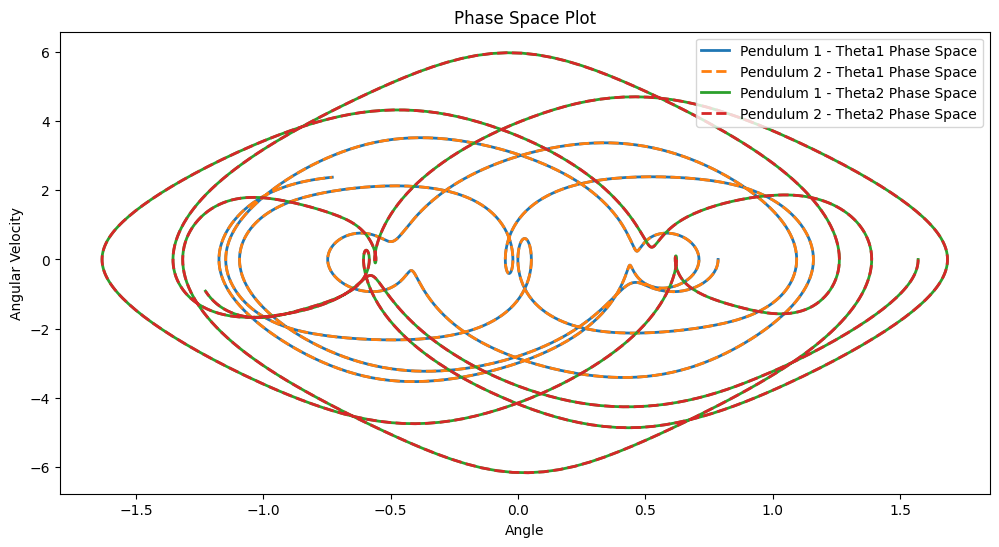

In [17]:
# Phase space plots
plt.figure(figsize=(12, 6))

# Theta1 vs Angular Velocity
plt.plot(sol_1.y[0], sol_1.y[1], label='Pendulum 1 - Theta1 Phase Space', linewidth=2)
plt.plot(sol_2.y[0], sol_2.y[1], label='Pendulum 2 - Theta1 Phase Space', linestyle='dashed', linewidth=2)

# Theta2 vs Angular Velocity
plt.plot(sol_1.y[2], sol_1.y[3], label='Pendulum 1 - Theta2 Phase Space', linewidth=2)
plt.plot(sol_2.y[2], sol_2.y[3], label='Pendulum 2 - Theta2 Phase Space', linestyle='dashed', linewidth=2)

plt.xlabel('Angle')
plt.ylabel('Angular Velocity')
plt.legend()
plt.title('Phase Space Plot')
plt.show()

Lyapunov exponents: [np.float64(200.44910187832372), np.float64(224.8006868700591), np.float64(225.29448396402634), np.float64(175.35198747357333), np.float64(186.558155183388), np.float64(184.6420087029292), np.float64(202.98912661029934), np.float64(132.1013318841217), np.float64(155.03484453679442), np.float64(168.6989267243953), np.float64(173.27916448307596), np.float64(193.5272210584018), np.float64(156.22625532973063), np.float64(143.7252892823724), np.float64(160.89540251843422), np.float64(157.75165421108576), np.float64(177.74177849079686), np.float64(199.6840785751206), np.float64(201.21182609036296), np.float64(139.5430237167864)]


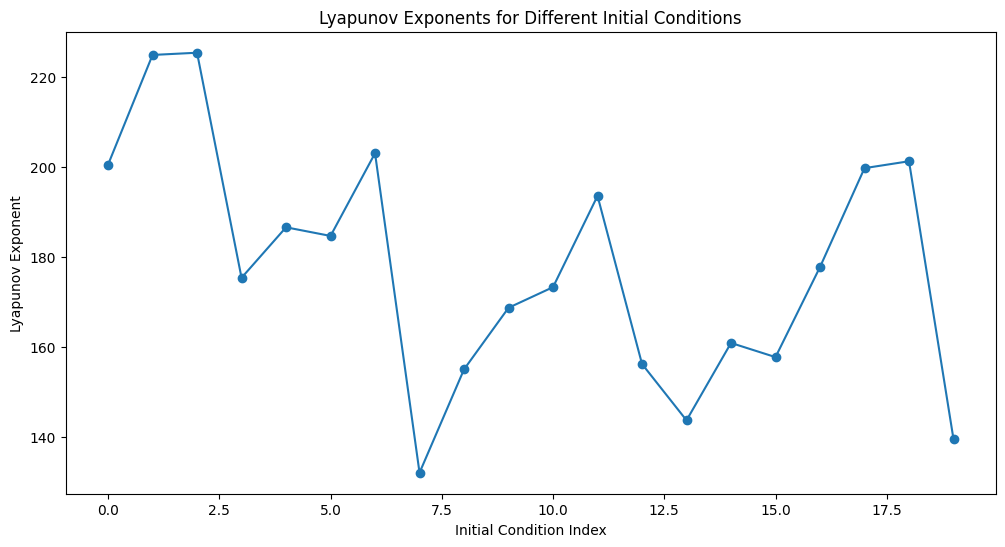

In [16]:
def lyapunov_exponent(y0, delta0, t_span, t_eval, L1, L2, m1, m2):
    sol = solve_ivp(double_pendulum, t_span, y0, args=(L1, L2, m1, m2), t_eval=t_eval)
    y0_perturbed = [y + delta0 for y in y0]
    sol_perturbed = solve_ivp(double_pendulum, t_span, y0_perturbed, args=(L1, L2, m1, m2), t_eval=t_eval)
    
    delta_t = np.sqrt((sol.y[0] - sol_perturbed.y[0])**2 + (sol.y[2] - sol_perturbed.y[2])**2)
    delta_t = np.where(delta_t == 0, 1e-10, delta_t)  # Avoid division by zero
    lambda_t = np.log(delta_t / delta0) / (t_eval[1] - t_eval[0])  # Use time step instead of entire array
    
    return np.mean(lambda_t)

# Calculate Lyapunov exponents for 20 different initial conditions
lyapunov_exponents = []
for i in range(20):  # Increase the number of initial conditions to 20
    y0 = [np.pi/4 + i*1e-3, 0, np.pi/2, 0]  # Increase the perturbation to 1e-3
    lyapunov_exp = lyapunov_exponent(y0, 1e-3, t_span, t_eval, L1, L2, m1, m2)
    lyapunov_exponents.append(lyapunov_exp)

# Debug print
print(f"Lyapunov exponents: {lyapunov_exponents}")

# Plot Lyapunov exponents
plt.figure(figsize=(12, 6))
plt.plot(range(20), lyapunov_exponents, marker='o')
plt.xlabel('Initial Condition Index')
plt.ylabel('Lyapunov Exponent')
plt.title('Lyapunov Exponents for Different Initial Conditions')
plt.show()